# 🦠 Exploratory Data Analysis (EDA)
**Project ResistAI**

In this notebook, we will explore our raw Antimicrobial Resistance (AMR) datasets. Our goals are to:
1. Understand the distribution of bacterial species and antibiotics.
2. Analyze the overall resistance vs. susceptibility rates.
3. Identify potential class imbalances that need to be addressed before modeling.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [5]:
# Load the datasets
try:
    df1 = pd.read_csv("../data/raw/Bacteria_dataset_Multiresictance.csv")
    try:
        df2 = pd.read_excel("../data/raw/Dataset.xlsx")
    except FileNotFoundError:
        df2 = pd.read_csv("../data/raw/Dataset.csv")
        
    df = pd.concat([df1, df2], ignore_index=True)
    print(f"Data loaded successfully. Total shape: {df.shape}")
except Exception as e:
    print(f"Error loading data: {e}")
    # Fallback to display mock structure if files aren't found in this specific path
    df = pd.DataFrame({'species': ['E. coli', 'S. aureus'], 'antibiotic': ['Ciprofloxacin', 'Methicillin'], 'susceptibility': ['Resistant', 'Susceptible']})

df.head()

Data loaded successfully. Total shape: (10984, 33)


,ID,Name,Email,Address,age/gender,Souches,Diabetes,Hypertension,Hospital_before,Infection_Freq,...,Furanes,colistine,Collection_Date,Notes,Location,IMIPENEM,CEFTAZIDIME,GENTAMICIN,AUGMENTIN,CIPROFLOXACIN
0,S290,Elizabeth Lawrence,elizabeth.lawrence@example.com,"6350 Robinson Loaf Apt. 447, Paulfurt, RI 30252",37/F,S290 Escherichia coli,No,No,No,0.0,...,S,S,5 Fev 2025,Patient had fever??,NaN,NaN,NaN,NaN,NaN,NaN
1,S291,Tina Sanders,tina.sanders@example.com,"78594 Galloway Port Suite 762, South Tanyatown...",29/F,S291 Morganella morganii,True,No,No,3.0,...,S,S,08/05/2021,تم العلاج,NaN,NaN,NaN,NaN,NaN,NaN
2,S292,Erin Cooke,erin.cooke@example.com,"76661 Isaiah Manors, North Benjamin, HI 85195",77/F,S292 Proteus mirabilis,True,No,No,3.0,...,S,S,01/05/2022,NADA,NaN,NaN,NaN,NaN,NaN,NaN
3,S293,Mrs. Sharon Watson,mrs..sharon.watson@example.com,"1670 Thompson Way Apt. 520, Andrewbury, IL 11534",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2020-01-05,PACIENTO ENFERMO,NaN,NaN,NaN,NaN,NaN,NaN
4,S294,Erika Stewart,erika.stewart@example.com,"76838 Patrick Green Suite 538, Torresmouth, ME...",13/F,S294 Escherichia coli,No,Yes,No,1.0,...,S,S,error,NADA,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Show all the column names
print("Columns in the dataset:")
print(df.columns.tolist())

# Show the first 3 rows of data
print("\nFirst 3 rows:")
display(df.head(3))

Columns in the dataset:
['ID', 'Name', 'Email', 'Address', 'age/gender', 'Souches', 'Diabetes', 'Hypertension', 'Hospital_before', 'Infection_Freq', 'AMX/AMP', 'AMC', 'CZ', 'FOX', 'CTX/CRO', 'IPM', 'GEN', 'AN', 'Acide nalidixique', 'ofx', 'CIP', 'C', 'Co-trimoxazole', 'Furanes', 'colistine', 'Collection_Date', 'Notes', 'Location', 'IMIPENEM', 'CEFTAZIDIME', 'GENTAMICIN', 'AUGMENTIN', 'CIPROFLOXACIN']

First 3 rows:


,ID,Name,Email,Address,age/gender,Souches,Diabetes,Hypertension,Hospital_before,Infection_Freq,...,Furanes,colistine,Collection_Date,Notes,Location,IMIPENEM,CEFTAZIDIME,GENTAMICIN,AUGMENTIN,CIPROFLOXACIN
0,S290,Elizabeth Lawrence,elizabeth.lawrence@example.com,"6350 Robinson Loaf Apt. 447, Paulfurt, RI 30252",37/F,S290 Escherichia coli,No,No,No,0.0,...,S,S,5 Fev 2025,Patient had fever??,NaN,NaN,NaN,NaN,NaN,NaN
1,S291,Tina Sanders,tina.sanders@example.com,"78594 Galloway Port Suite 762, South Tanyatown...",29/F,S291 Morganella morganii,True,No,No,3.0,...,S,S,08/05/2021,تم العلاج,NaN,NaN,NaN,NaN,NaN,NaN
2,S292,Erin Cooke,erin.cooke@example.com,"76661 Isaiah Manors, North Benjamin, HI 85195",77/F,S292 Proteus mirabilis,True,No,No,3.0,...,S,S,01/05/2022,NADA,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# Print all the column names in our dataset
print(df.columns.tolist())

['ID', 'Name', 'Email', 'Address', 'age/gender', 'Souches', 'Diabetes', 'Hypertension', 'Hospital_before', 'Infection_Freq', 'AMX/AMP', 'AMC', 'CZ', 'FOX', 'CTX/CRO', 'IPM', 'GEN', 'AN', 'Acide nalidixique', 'ofx', 'CIP', 'C', 'Co-trimoxazole', 'Furanes', 'colistine', 'Collection_Date', 'Notes', 'Location', 'IMIPENEM', 'CEFTAZIDIME', 'GENTAMICIN', 'AUGMENTIN', 'CIPROFLOXACIN']


Data successfully reshaped! New shape: (152534, 4)


C:\Users\DIVYANSHU\AppData\Local\Temp\ipykernel_3628\3744951338.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=melted_df, x='resistance_label', palette=['#e74c3c', '#2ecc71'], ax=axes[0])
C:\Users\DIVYANSHU\AppData\Local\Temp\ipykernel_3628\3744951338.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_species.values, y=top_species.index, ax=axes[1], palette='viridis')
C:\Users\DIVYANSHU\AppData\Local\Temp\ipykernel_3628\3744951338.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_abx.values, y=top_abx.index, ax=

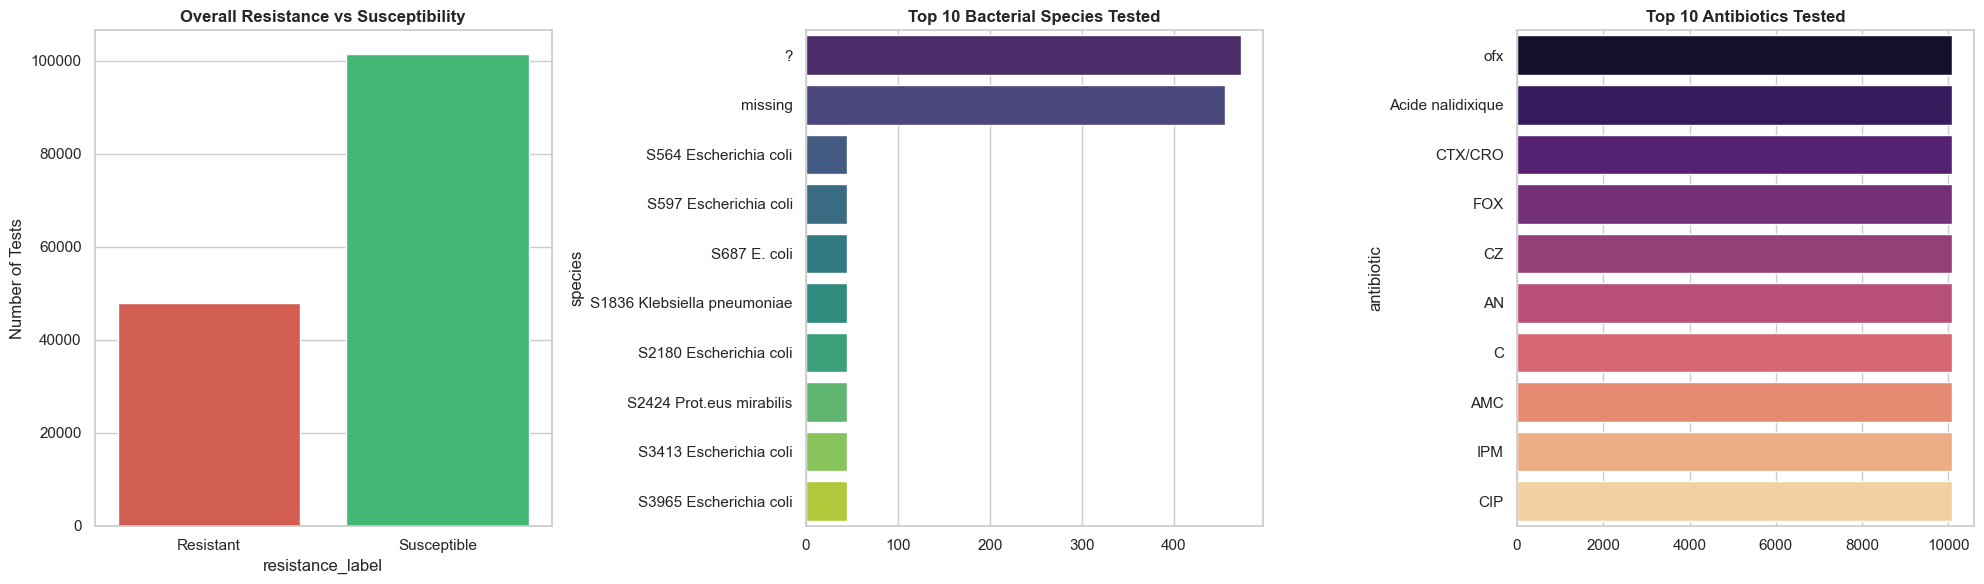

In [9]:
#  Define our list of antibiotic columns based on your output
abx_columns = [
    'AMX/AMP', 'AMC', 'CZ', 'FOX', 'CTX/CRO', 'IPM', 'GEN', 'AN', 
    'Acide nalidixique', 'ofx', 'CIP', 'C', 'Co-trimoxazole', 'Furanes', 
    'colistine', 'IMIPENEM', 'CEFTAZIDIME', 'GENTAMICIN', 'AUGMENTIN', 'CIPROFLOXACIN'
]

#  Reshape (melt) the dataframe from Wide to Long format
# We keep 'Souches' (the species) and stack all the antibiotics into two new columns
melted_df = df.melt(
    id_vars=['Souches'], 
    value_vars=abx_columns, 
    var_name='antibiotic', 
    value_name='susceptibility'
)

#  Clean up the reshaped data
# Drop rows where the test wasn't performed (NaN)
melted_df = melted_df.dropna(subset=['susceptibility'])

# Rename 'Souches' to 'species' so it matches the rest of our pipeline!
melted_df = melted_df.rename(columns={'Souches': 'species'})

# Map the values to a clean Resistant/Susceptible binary
# Sometimes datasets use 'R' and 'S' instead of the full words, so we handle both just in case!
res_mapping = {
    'Resistant': 'Resistant', 'R': 'Resistant', 'r': 'Resistant',
    'Susceptible': 'Susceptible', 'S': 'Susceptible', 's': 'Susceptible',
    'Intermediate': 'Susceptible', 'I': 'Susceptible', 'i': 'Susceptible'
}
melted_df['resistance_label'] = melted_df['susceptibility'].map(res_mapping)

print(f"Data successfully reshaped! New shape: {melted_df.shape}")


fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Chart 1: Overall Resistance
sns.countplot(data=melted_df, x='resistance_label', palette=['#e74c3c', '#2ecc71'], ax=axes[0])
axes[0].set_title('Overall Resistance vs Susceptibility', fontweight='bold')
axes[0].set_ylabel('Number of Tests')

# Chart 2: Top Bacteria
top_species = melted_df['species'].value_counts().head(10)
sns.barplot(x=top_species.values, y=top_species.index, ax=axes[1], palette='viridis')
axes[1].set_title('Top 10 Bacterial Species Tested', fontweight='bold')

# Chart 3: Top Antibiotics
top_abx = melted_df['antibiotic'].value_counts().head(10)
sns.barplot(x=top_abx.values, y=top_abx.index, ax=axes[2], palette='magma')
axes[2].set_title('Top 10 Antibiotics Tested', fontweight='bold')

plt.tight_layout()
plt.show()